In [19]:
# Task 1. Date Feature Engineering

import pandas as pd
df = pd.read_csv('D:\BA\BITSoM BA Assignment Datasets\ml-assessment-nishant-saxena\data\q3_retail_promotions.csv')

#convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

#extracting year, month, day_of_week
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end binary feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

<>:4: SyntaxWarning: invalid escape sequence '\B'
<>:4: SyntaxWarning: invalid escape sequence '\B'
C:\Users\nisha\AppData\Local\Temp\ipykernel_70424\676200233.py:4: SyntaxWarning: invalid escape sequence '\B'
  df = pd.read_csv('D:\BA\BITSoM BA Assignment Datasets\ml-assessment-nishant-saxena\data\q3_retail_promotions.csv')


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [20]:
# Task 2. Temporal Train-Test Split
df = df.sort_values(by='transaction_date')

# split
split_index = int(0.8 * len(df))

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

#separate features and target
X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df['items_sold']

X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df['items_sold']

A random split is inappropriate for time-ordered data because it can lead to data leakage, where future information is used to predict past outcomes.
In real-world scenarios, models only have access to past data to predict the future. Therefore, a temporal split ensures that the training set contains earlier data and the test set contains more recent data, making evaluation realistic. 

In [21]:
#Task 3. Preprocessing Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#Columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

#Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [22]:
# Task 4. Model Training and Evaluation

In [23]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
]) 

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr) 

print("Linear Regression - RMSE:", rmse_lr)
print("Linear Regression - MAE:", mae_lr)

Linear Regression - RMSE: 27.12145116489063
Linear Regression - MAE: 21.052926674588395


In [24]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest - RMSE:", rmse_rf)
print("Random Forest - MAE:", mae_rf)

Random Forest - RMSE: 30.840947138774233
Random Forest - MAE: 24.306125


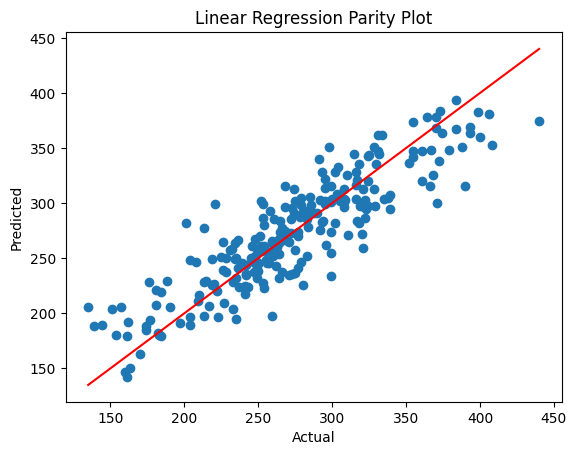

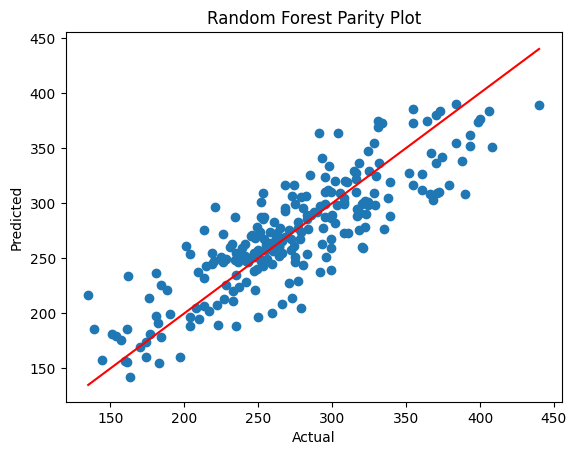

In [25]:
#Parity Plot

import matplotlib.pyplot as plt
def parity_plot(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred)
    plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         color='red')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title)
    plt.show()

parity_plot(y_test, y_pred_lr, "Linear Regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random Forest Parity Plot")

In [26]:
#get feature names afetr preprocessing

ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_cols = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_cat_cols) + numerical_cols

#importance
importances = rf_pipeline.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)
feat_imp.head(10)

,feature,importance
2,promotion_type_flat_discount,0.173413
18,is_month_end,0.166752
15,year,0.108505
6,location_type_semi-urban,0.080552
1,promotion_type_category_offer,0.067103
0,promotion_type_bogo,0.054821
13,is_festival,0.052593
3,promotion_type_free_gift,0.050869
16,month,0.049790
5,location_type_rural,0.037345


The top 5 most influential features affecting items_sold are:

1. promotion_type_flat_discount
2. is_month_end
3. year
4. location_type_semi-urban
5. promotion_type_category_offer